In [13]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
from PIL import Image, ImageDraw

# Segmentation


## Segment into 5 sectors

In [3]:
img_dir = Path('/Users/pedrobaeza/Desktop/Image and pattern recognition/Data para projecto/iapr-26-uno-vision-challenge/train_images')
image_paths = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png")) + list(img_dir.glob("*.jpeg"))

print(f"Total of images: {len(image_paths)}")

Total of images: 81


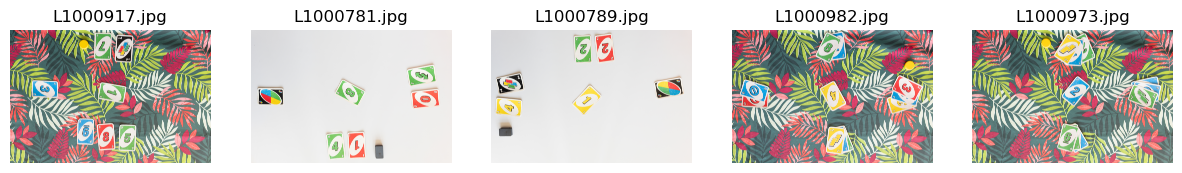

In [4]:
sample_paths = random.sample(image_paths, 5)

plt.figure(figsize=(15, 5))

for i, path in enumerate(sample_paths):
    img = Image.open(path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(path.name)
    plt.axis("off")

plt.show()

In [5]:
#Know sizes
sizes = set()

for path in image_paths:
    img = Image.open(path)
    sizes.add(img.size)

print(sizes)

{(4000, 2662)}


In [6]:
#Draw aproximation lines of the 5 sectors
import random
from PIL import Image
import matplotlib.pyplot as plt

# Lines coordinates
x_left = 980
x_mid_left = 1250
x_mid_right = 2700
x_right = 3100

y_top_left = 500
y_top = 850
y_bottom = 1900
y_bottom_right = 2200

def show_sectors(img_path):
    img = Image.open(img_path)
    width, height = img.size

    plt.figure(figsize=(12, 8))
    plt.imshow(img)

    # Top-left step (horizontal + small vertical drop)
    plt.plot([0, x_left], [y_top_left, y_top_left], color="black", linewidth=4)
    plt.plot([x_left, x_left], [y_top_left, y_top], color="black", linewidth=4)

    # Main top horizontal line
    plt.plot([x_left, x_right], [y_top, y_top], color="black", linewidth=4)

    # Left vertical (ONLY bottom segment, removed upper part)
    plt.plot([x_left, x_left], [y_bottom, height], color="black", linewidth=4)

    # Central vertical separators (define middle sectors)
    plt.plot([x_mid_left, x_mid_left], [y_top, y_bottom], color="black", linewidth=4)
    plt.plot([x_mid_right, x_mid_right], [y_top, y_bottom], color="black", linewidth=4)

    # Main bottom horizontal line
    plt.plot([x_left, x_right], [y_bottom, y_bottom], color="black", linewidth=4)

    # Right vertical (ONLY upper segment, removed middle part)
    plt.plot([x_right, x_right], [0, y_top], color="black", linewidth=4)

    # Bottom-right step (small vertical + horizontal extension)
    plt.plot([x_right, x_right], [y_bottom, y_bottom_right], color="black", linewidth=4)
    plt.plot([x_right, width], [y_bottom_right, y_bottom_right], color="black", linewidth=4)

    plt.axis("off")
    plt.show()

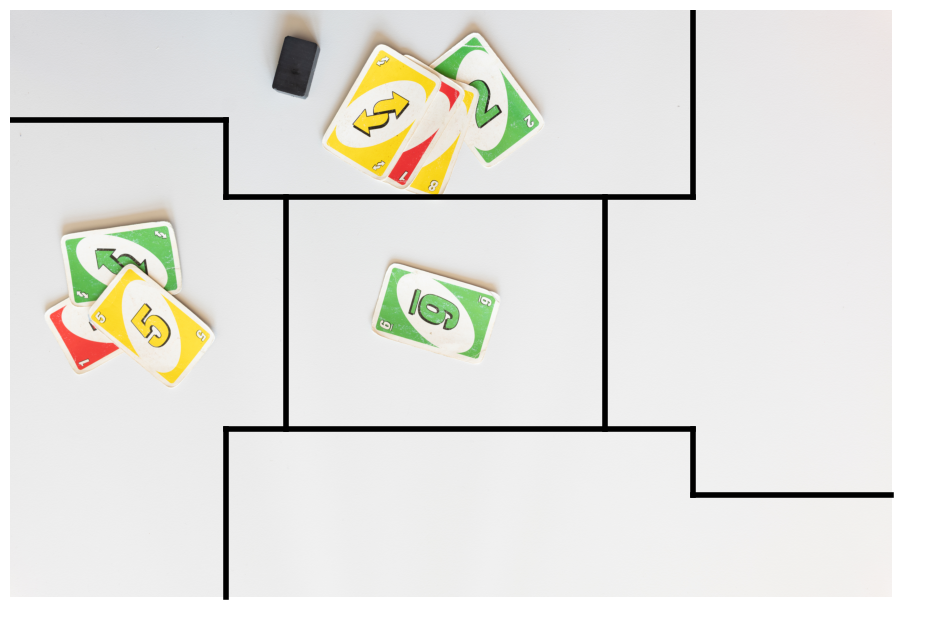

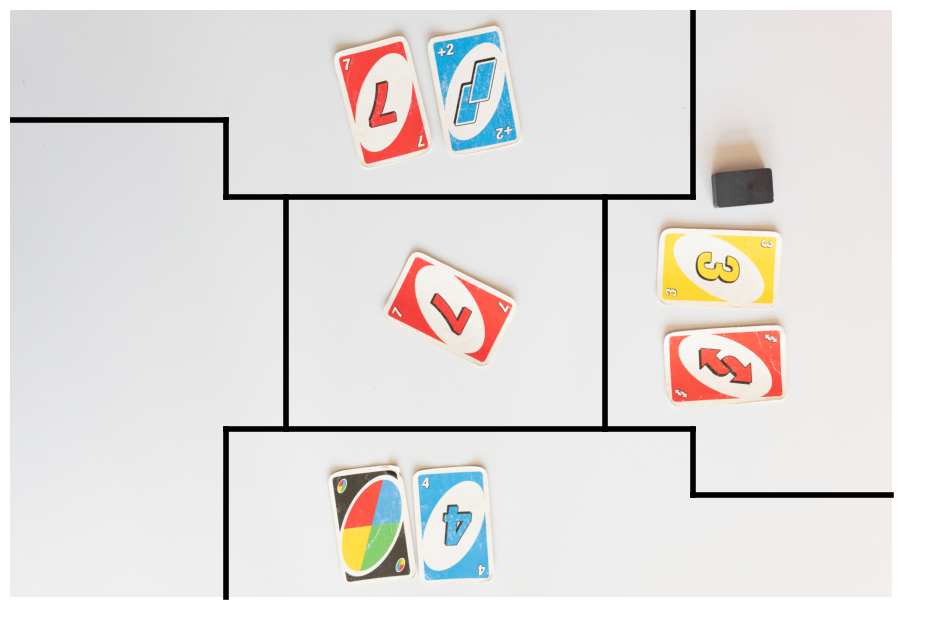

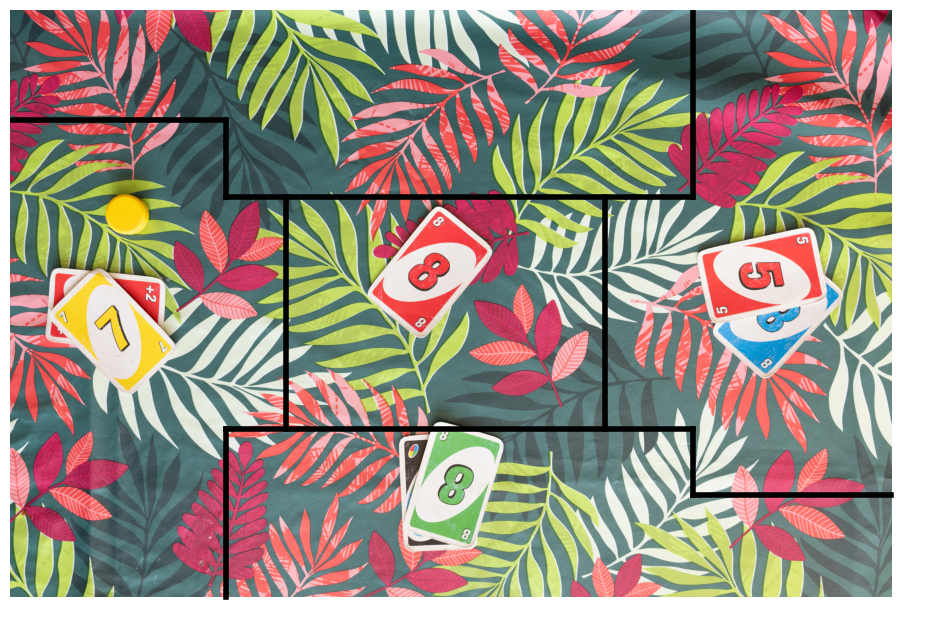

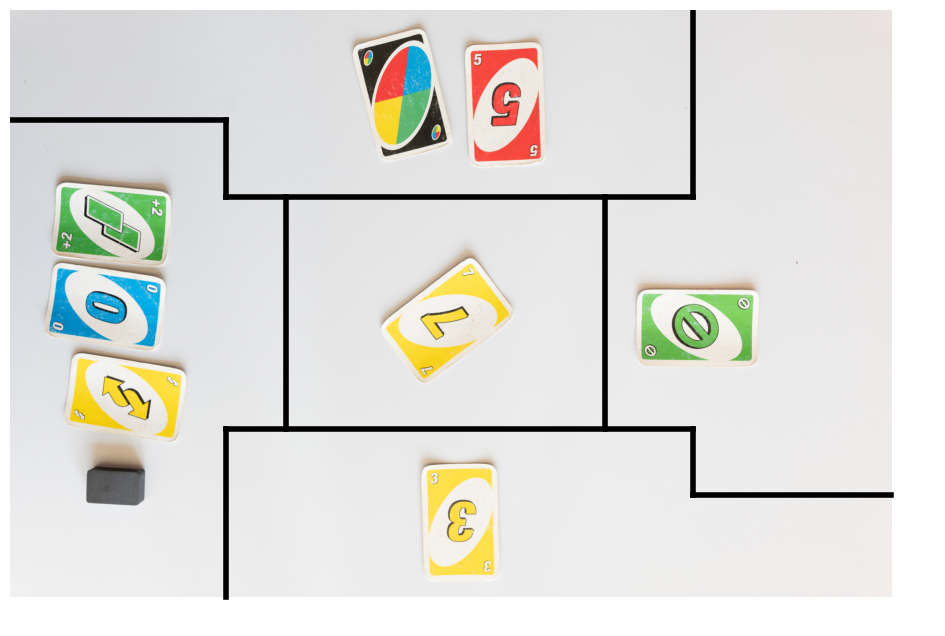

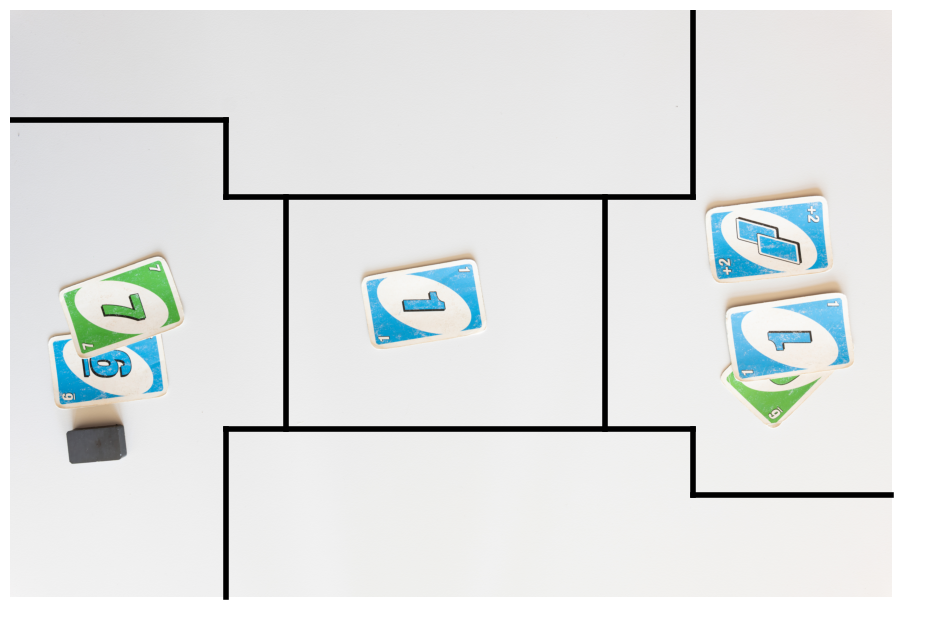

In [7]:
sample_paths = random.sample(image_paths, 5)

for path in sample_paths:
    show_sectors(path)

In [8]:
def get_sector_polygons(img):
    width, height = img.size

    polygons = {
        "Player 3": [
            (0, 0),
            (x_right, 0),
            (x_right, y_top),
            (x_left, y_top),
            (x_left, y_top_left),
            (0, y_top_left)
        ],

        "Player 4": [
            (0, y_top_left),
            (x_left, y_top_left),
            (x_left, y_top),
            (x_mid_left, y_top),
            (x_mid_left, y_bottom),
            (x_left, y_bottom),
            (x_left, height),
            (0, height)
        ],

        

        "Center": [
            (x_mid_left, y_top),
            (x_mid_right, y_top),
            (x_mid_right, y_bottom),
            (x_mid_left, y_bottom)
        ],

        "Player 2": [
            (x_right, 0),
            (width, 0),
            (width, y_bottom_right),
            (x_right, y_bottom_right),
            (x_right, y_bottom),
            (x_mid_right, y_bottom),
            (x_mid_right, y_top),
            (x_right, y_top)
        ],

        "Player 1": [
            (x_left, y_bottom),
            (x_right, y_bottom),
            (x_right, y_bottom_right),
            (width, y_bottom_right),
            (width, height),
            (x_left, height)
        ]
    }

    return polygons

In [9]:
def extract_sector(img, polygon):
    width, height = img.size

    mask = Image.new("L", (width, height), 0)
    draw = ImageDraw.Draw(mask)
    draw.polygon(polygon, fill=255)

    bbox = mask.getbbox()

    sector = Image.new("RGB", (width, height), "white")
    sector.paste(img, mask=mask)

    sector_crop = sector.crop(bbox)
    mask_crop = mask.crop(bbox)

    return sector_crop, mask_crop

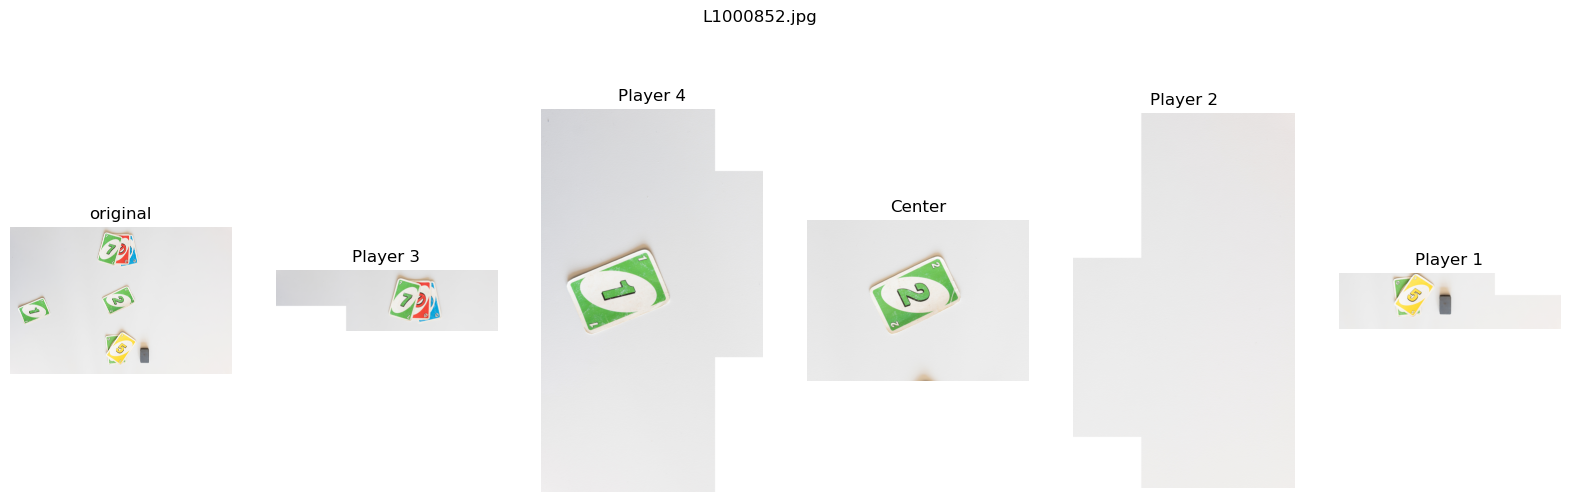

In [14]:
path = random.choice(image_paths)
img = Image.open(path).convert("RGB")

polygons = get_sector_polygons(img)

results = {"original": img}

for name, poly in polygons.items():
    sector, _ = extract_sector(img, poly)
    results[name] = sector

# Plot all together
plt.figure(figsize=(20, 6))

for i, (name, sector) in enumerate(results.items()):
    plt.subplot(1, len(results), i + 1)
    plt.imshow(sector)
    plt.title(name)
    plt.axis("off")

plt.suptitle(path.name)
plt.show()

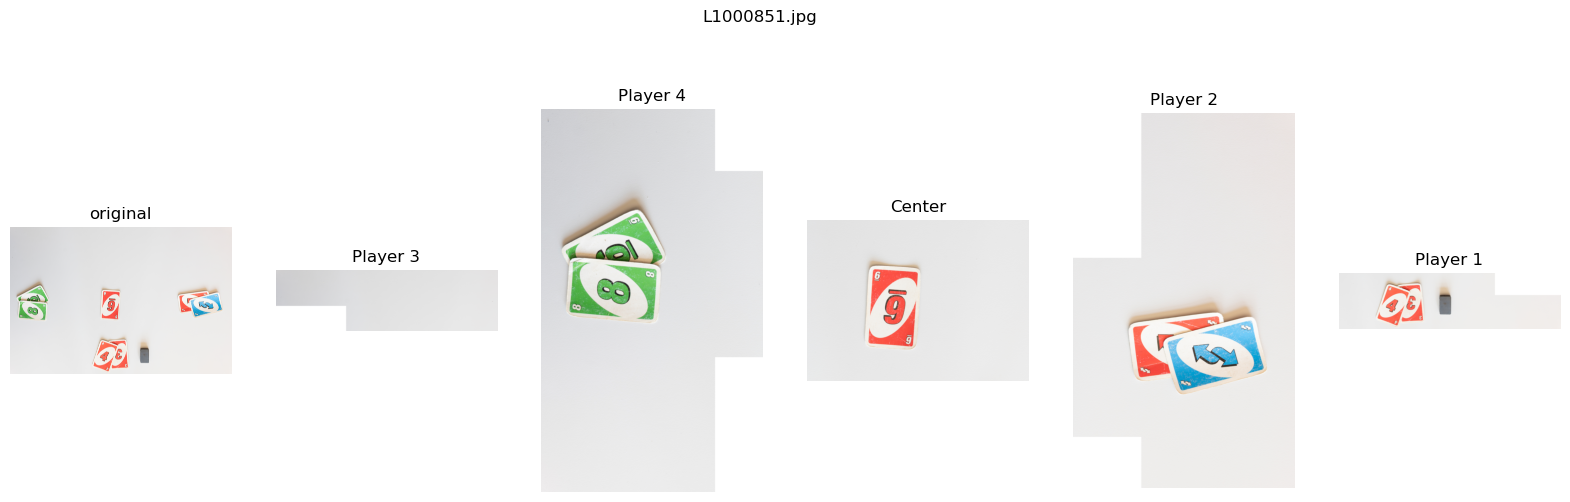

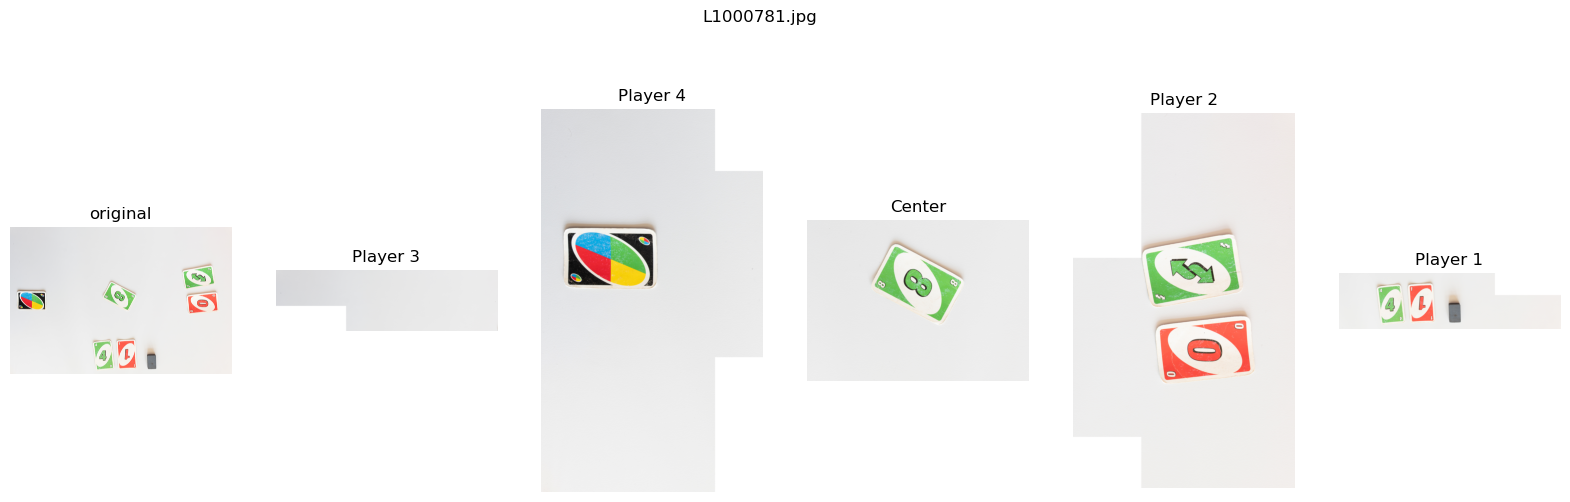

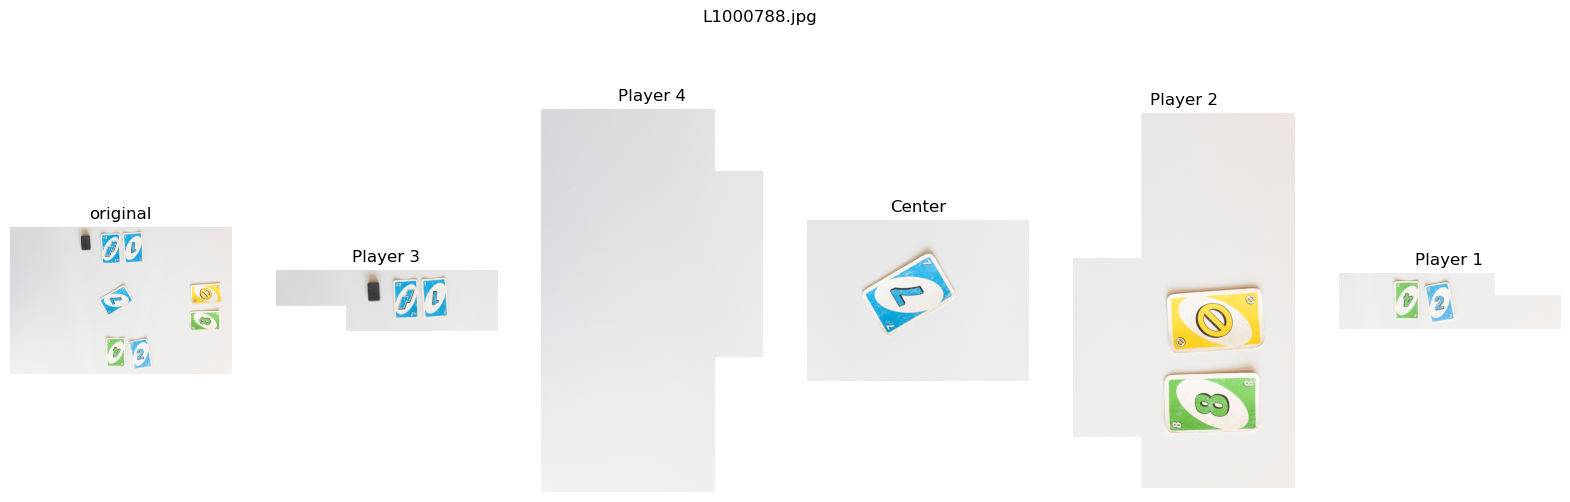

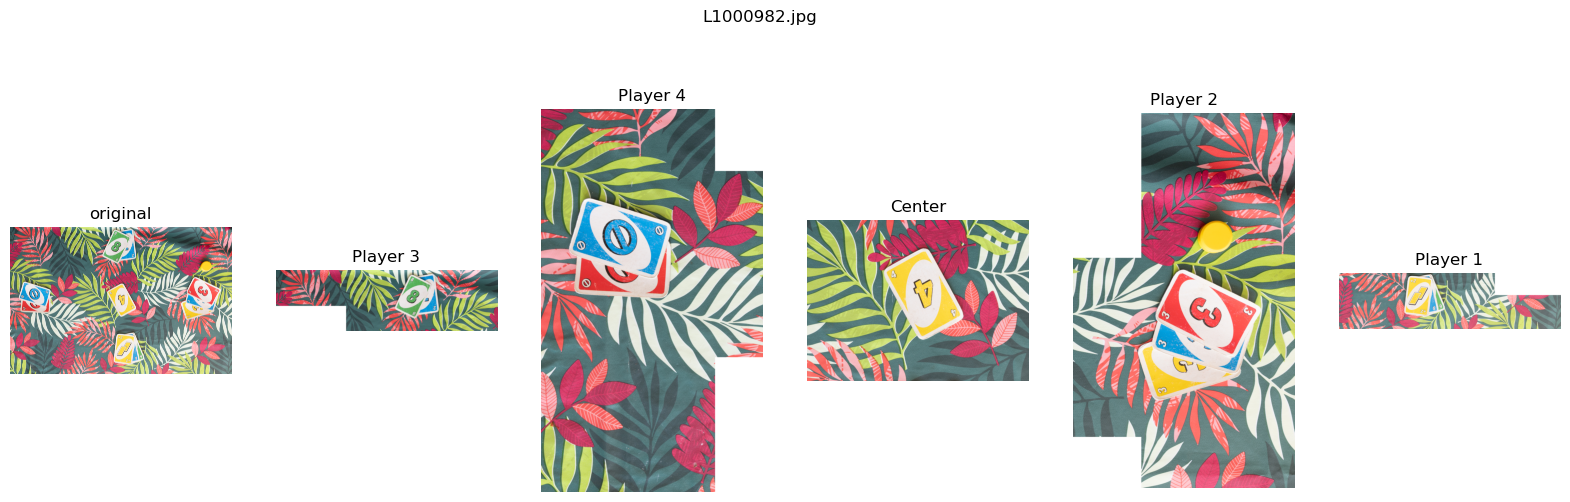

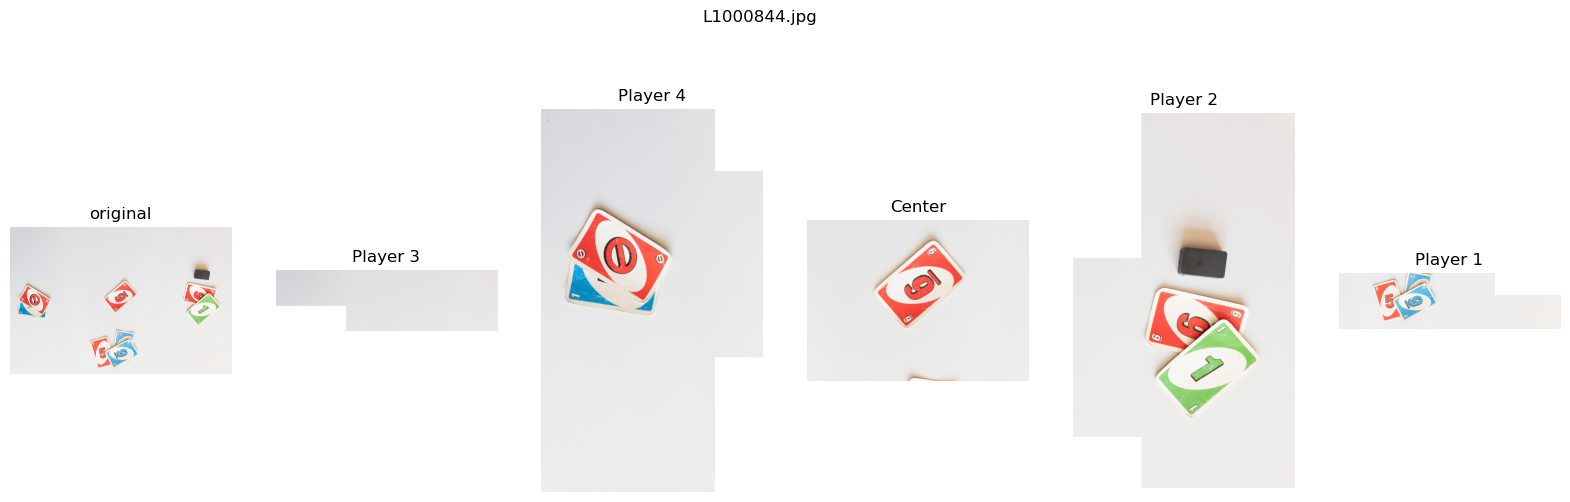

In [24]:
samples = random.sample(image_paths, 5)

for path in samples:
    img = Image.open(path).convert("RGB")
    polygons = get_sector_polygons(img)

    results = {"original": img}

    for name, poly in polygons.items():
        sector, _ = extract_sector(img, poly)
        results[name] = sector

    # Plot per image
    plt.figure(figsize=(20, 6))

    for i, (name, sector) in enumerate(results.items()):
        plt.subplot(1, len(results), i + 1)
        plt.imshow(sector)
        plt.title(name)
        plt.axis("off")

    plt.suptitle(path.name)
    plt.show()

## Segment cards

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def segment_colors(sector_img):
    img = np.array(sector_img)

    # RGB to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    masks = {}

    # Blue
    masks["blue"] = cv2.inRange(
        hsv,
        np.array([90, 50, 50]),
        np.array([130, 255, 255])
    )

    # Green
    masks["green"] = cv2.inRange(
        hsv,
        np.array([35, 40, 40]),
        np.array([85, 255, 255])
    )

    # Yellow
    masks["yellow"] = cv2.inRange(
        hsv,
        np.array([18, 50, 50]),
        np.array([35, 255, 255])
    )

    # Red has two hue ranges in HSV
    red1 = cv2.inRange(hsv, np.array([0, 50, 50]), np.array([10, 255, 255]))
    red2 = cv2.inRange(hsv, np.array([170, 50, 50]), np.array([180, 255, 255]))
    masks["red"] = red1 | red2

    return masks

In [27]:
#Print sectors
def show_color_segmentation_by_sector(img_path):
    img = Image.open(img_path).convert("RGB")
    polygons = get_sector_polygons(img)

    print(img_path.name)

    for sector_name, poly in polygons.items():
        sector, _ = extract_sector(img, poly)
        masks = segment_colors(sector)

        plt.figure(figsize=(18, 4))

        # Original sector
        plt.subplot(1, 5, 1)
        plt.imshow(sector)
        plt.title(f"{sector_name}")
        plt.axis("off")

        # Color masks
        for i, (color_name, mask) in enumerate(masks.items()):
            plt.subplot(1, 5, i + 2)
            plt.imshow(mask, cmap="gray")
            plt.title(color_name)
            plt.axis("off")

        plt.show()

L1000909.jpg


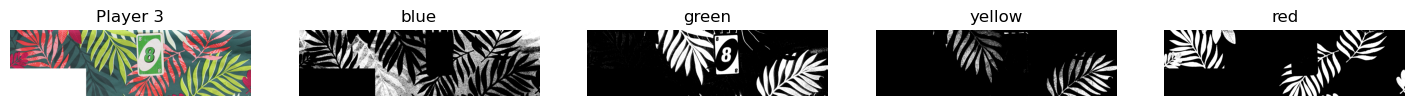

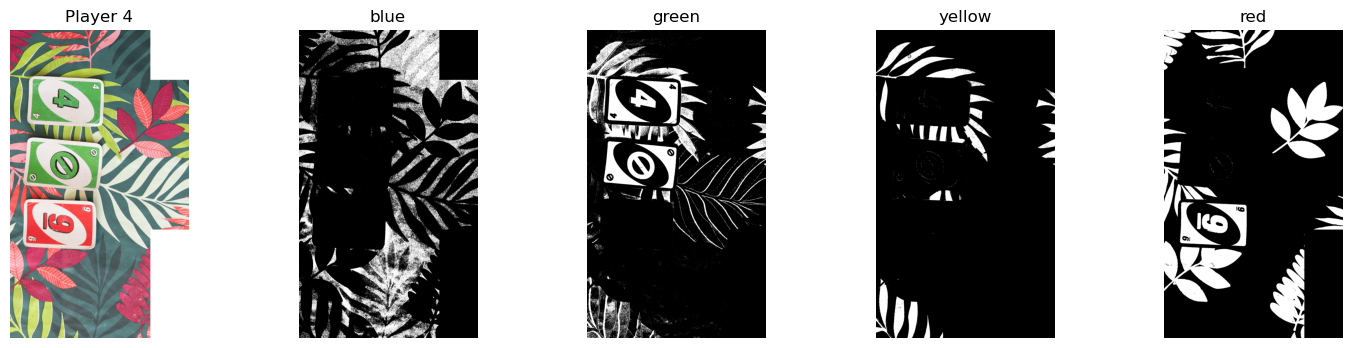

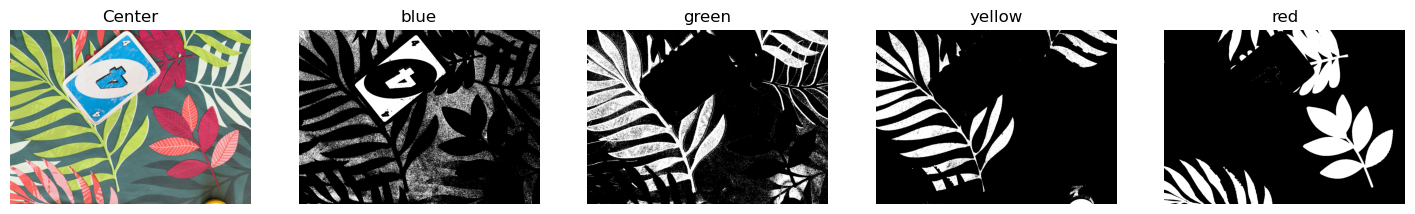

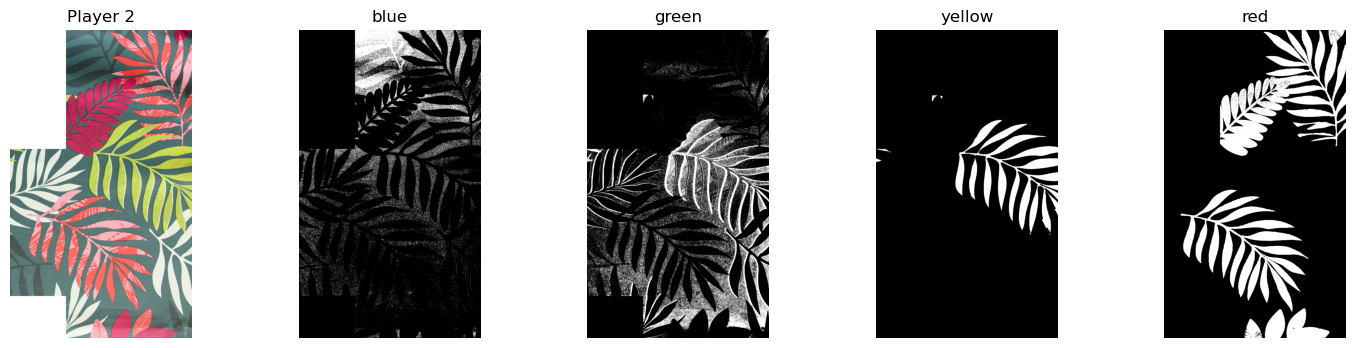

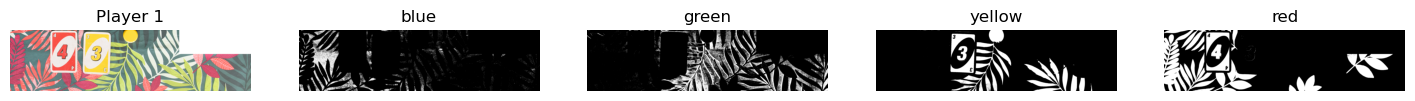

In [34]:
path = random.choice(image_paths)
show_color_segmentation_by_sector(path)